In [3]:
# Cell 1: Setup and Loading the Data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Load the dataset
# Tell pandas to read the CSV file from your folder and store it in a variable called 'df' (DataFrame)
df = pd.read_csv('telecom_web_logs_dataset.csv')

# 2. Display basic information
# Print the 'shape' of the dataframe (which outputs: [number of rows, number of columns])
print("Dataset Shape:", df.shape)
print("\n--- First 3 Rows ---")
display(df.head(3))

Dataset Shape: (100000, 23)

--- First 3 Rows ---


,timestamp,session_id,ip_address,user_agent,http_method,endpoint,status_code,response_size,device_type,user_role,...,isp,threat_type,is_malicious,request_duration_ms,http_headers,related_session,correlation_type,requests_per_session,error_rate,is_api
0,2025-03-23T12:30:55.561645,e734f4a1-dd64-4fa8-ba53-97ca639d1841,10.11.38.108,Android 2.3.2,POST,/api/v2/home,201,56,mobile,api_client,...,Internal Network,normal,0,207,"{""Accept"": ""*/*"", ""Accept-Language"": ""zu-TZ"", ...",NaN,NaN,1000,0,1
1,2025-03-23T12:30:56.495447,e734f4a1-dd64-4fa8-ba53-97ca639d1841,87.23.216.245,Android 2.3.3,GET,/admin/dashboard,200,33368,mobile,customer,...,Orange,normal,0,205,"{""Accept"": ""application/json"", ""Accept-Languag...",NaN,NaN,1000,0,0
2,2025-03-23T12:30:56.770971,e734f4a1-dd64-4fa8-ba53-97ca639d1841,137.13.222.203,Mozilla/5.0 (iPhone; CPU iPhone OS 17_1_2 like...,GET,/products,200,43683,desktop,partner,...,Vodafone,normal,0,222,"{""Accept"": ""application/json"", ""Accept-Languag...",NaN,NaN,1000,0,0


In [130]:
# Cell 2: Feature Engineering (Making data AI-readable)

In [131]:
# Create a copy so we don't mess up the original dataframe
df_processed = df.copy()

# 1. Handle the Timestamp
# We extract the 'Hour' because cyber attacks often happen at unusual hours (e.g., 3 AM)
df_processed['timestamp'] = pd.to_datetime(df_processed['timestamp'])
df_processed['hour_of_day'] = df_processed['timestamp'].dt.hour

# 2. Drop columns that are completely useless for the AI pattern recognition
# (e.g., session_id is just random letters, and we already know there are no malicious flags)
cols_to_drop = ['timestamp', 'session_id', 'threat_type', 'is_malicious', 'related_session', 'correlation_type', 'http_headers']
df_processed = df_processed.drop(columns=cols_to_drop, errors='ignore')

# 3. Encode Categorical Variables (Text to Numbers)
# We use LabelEncoder to turn categories into numbers (e.g., GET=0, POST=1)
categorical_cols = ['ip_address', 'user_agent', 'http_method', 'endpoint', 'device_type', 'user_role', 'country', 'city', 'asn', 'isp']

le_dict = {} # Dictionary to save our encoders in case we need them later
for col in categorical_cols:
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    le_dict[col] = le

# 4. Scale Numerical Variables
# AI models get confused if one column has huge numbers (response_size: 40000) and another has tiny numbers (is_api: 1).
# StandardScaler shrinks everything to a similar scale.
numerical_cols = ['status_code', 'response_size', 'request_duration_ms', 'requests_per_session', 'error_rate', 'hour_of_day']

scaler = StandardScaler()
df_processed[numerical_cols] = scaler.fit_transform(df_processed[numerical_cols])

print("Data processing complete! Here is what the AI will actually see:")
display(df_processed.head())

Data processing complete! Here is what the AI will actually see:


,ip_address,user_agent,http_method,endpoint,status_code,response_size,device_type,user_role,country,city,asn,isp,request_duration_ms,requests_per_session,error_rate,is_api,hour_of_day
0,390,19,1,6,-0.162258,-0.882022,2,1,0,9957,41286,2,0.593967,0.0,-0.181906,1,0.067693
1,96683,20,0,1,-0.190160,1.150497,2,2,1,16922,12992,3,0.530667,0.0,-0.181906,0,0.067693
2,14500,32276,0,9,-0.190160,1.779863,0,3,1,24858,34168,5,1.068717,0.0,-0.181906,0,0.067693
3,70412,23277,1,1,-0.162258,-0.879520,0,2,0,16051,22095,1,-0.070684,0.0,-0.181906,0,0.067693
4,45553,64,1,7,-0.162258,-0.868599,2,1,4,9957,41286,2,-0.766984,0.0,-0.181906,1,0.067693


In [132]:
# Cell 3: Visualizing the Data (Correlation Heatmap)

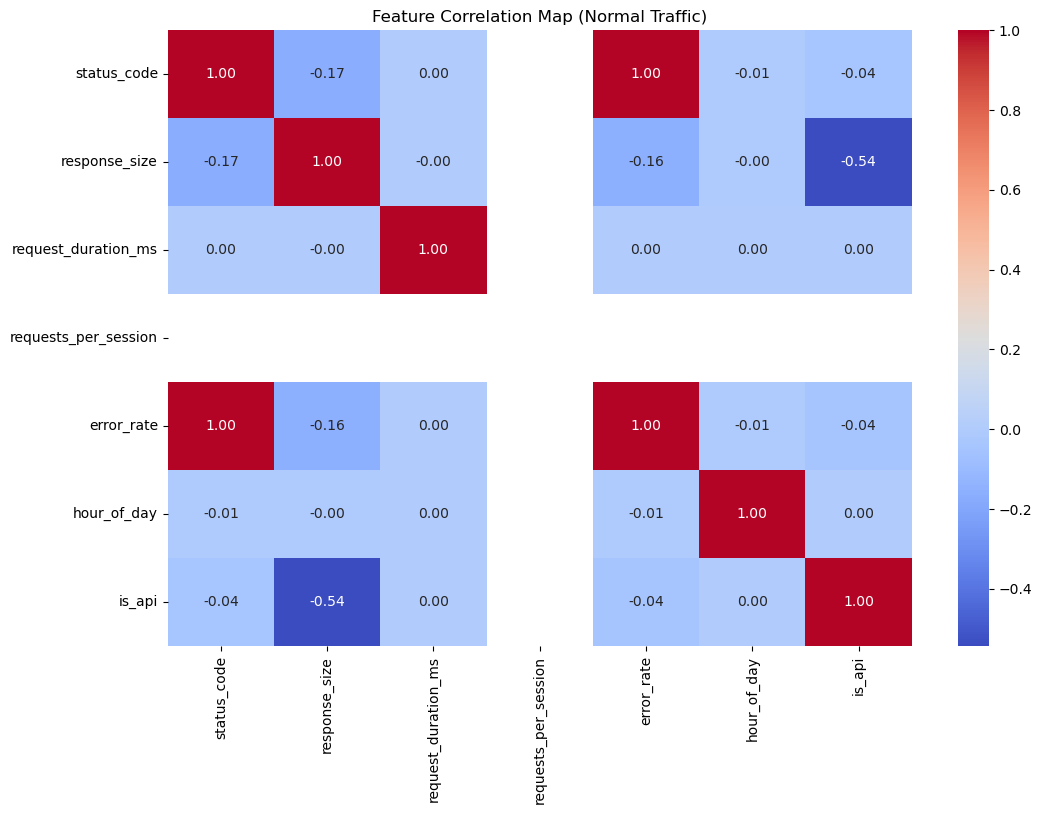

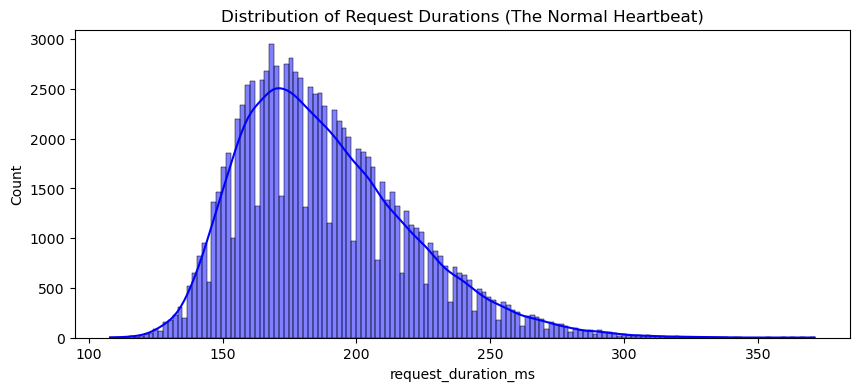

In [133]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a correlation heatmap
plt.figure(figsize=(12, 8))
# We select only a few interesting columns to keep the map readable
interest_cols = ['status_code', 'response_size', 'request_duration_ms', 
                 'requests_per_session', 'error_rate', 'hour_of_day', 'is_api']

sns.heatmap(df_processed[interest_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Map (Normal Traffic)")
plt.show()

# Visualize the distribution of Request Durations
plt.figure(figsize=(10, 4))
sns.histplot(df['request_duration_ms'], kde=True, color='blue')
plt.title("Distribution of Request Durations (The Normal Heartbeat)")
plt.show()

In [134]:
# Cell 4: Training the Isolation Forest, Model Building (Threat Prediction)

In [135]:
from sklearn.ensemble import IsolationForest


# 1. The Pro-Move: Automatically drop any column that has no variance (all same numbers)
cols_to_drop_variance = [col for col in df_processed.columns if df_processed[col].nunique() <= 1]
print(f"Dropping useless constant columns: {cols_to_drop_variance}")
df_processed = df_processed.drop(columns=cols_to_drop_variance)

# 2. Train the Isolation Forest
print("\nTraining Isolation Forest (This might take a few seconds)...")
# 'contamination=0.01' means we tell the AI: "Assume 1% of this 'normal' data might actually be hidden noise or undetected anomalies."
iso_forest = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)

# Fit the model on your clean, scaled data
iso_forest.fit(df_processed)

# 3. Generate Predictions
# The model returns 1 for Normal, and -1 for Anomaly
predictions = iso_forest.predict(df_processed)

# 4. Generate Anomaly Scores
# Negative scores indicate anomalies. The more negative, the worse the threat.
scores = iso_forest.decision_function(df_processed)

# Add the results back to our ORIGINAL dataframe so we can read them easily
df['anomaly_score'] = scores
df['is_anomaly'] = predictions

print("\n--- Model Training Complete! ---")
print("Anomaly Breakdown (-1 = Anomaly, 1 = Normal):")
print(df['is_anomaly'].value_counts())

# Let's look at the top 3 most "anomalous" requests the AI found in your normal data
print("\nTop 3 Anomalies found by the AI:")
display(df[df['is_anomaly'] == -1].sort_values(by='anomaly_score').head(3))

Dropping useless constant columns: ['requests_per_session']

Training Isolation Forest (This might take a few seconds)...

--- Model Training Complete! ---
Anomaly Breakdown (-1 = Anomaly, 1 = Normal):
is_anomaly
 1    99000
-1     1000
Name: count, dtype: int64

Top 3 Anomalies found by the AI:


,timestamp,session_id,ip_address,user_agent,http_method,endpoint,status_code,response_size,device_type,user_role,country,city,asn,isp,threat_type,is_malicious,request_duration_ms,http_headers,related_session,correlation_type,requests_per_session,error_rate,is_api,anomaly_score,is_anomaly
36683,2025-03-23T20:40:05.307492,649faec6-50c9-4500-972e-34783171f460,18.33.120.51,Mozilla/5.0 (Macintosh; U; PPC Mac OS X 10_8_7; rv:1.9.4.20) Gecko/9433-07-11 08:05:19.612152 Firefox/3.6.20,GET,/api/v2/products,404,359,desktop,admin,DE,West Stephenstad,AS14496,Verizon,normal,0,187,"{""Accept"": ""application/json"", ""Accept-Language"": ""hr-CZ"", ""X-Forwarded-For"": """", ""Referer"": """"}",NaN,NaN,1000,1,1,-0.067040,-1
51024,2025-03-23T23:52:00.108797,6ac1c74f-7af8-46bc-a7db-ddeab5dca94f,209.10.183.178,"Mozilla/5.0 (Linux; Android 7.0) AppleWebKit/536.2 (KHTML, like Gecko) Chrome/56.0.853.0 Safari/536.2",GET,/api/v2/account,404,284,desktop,admin,US,West Benjamin,AS20310,Vodafone,normal,0,192,"{""Accept"": ""*/*"", ""Accept-Language"": ""nhn-SM"", ""X-Forwarded-For"": """", ""Referer"": ""https://www.Verizon.comlist/explore/posts""}",NaN,NaN,1000,1,1,-0.055851,-1
37127,2025-03-23T20:46:00.362849,0fe0bc35-f274-479b-be11-531e5e390afd,151.231.23.101,"Mozilla/5.0 (Windows NT 10.0) AppleWebKit/531.0 (KHTML, like Gecko) Chrome/40.0.832.0 Safari/531.0",GET,/api/users,404,247,desktop,partner,FR,New Marcus,AS13001,AT&T,normal,0,290,"{""Accept"": ""application/json"", ""Accept-Language"": ""hne-DZ"", ""X-Forwarded-For"": ""151.231.23.101"", ""Referer"": """"}",NaN,NaN,1000,1,1,-0.053193,-1


In [49]:
# Cell 5: XAI (Explainable AI)

In [139]:
# --- STEP 5a: The Master Anomaly Tracking Table ---

print("📋 DISPLAYING A SAMPLE OF THE ANOMALIES FOUND BY THE AI")
print("-" * 80)

# 1. Create a copy of just the anomalies
all_anomalies = df[df['is_anomaly'] == -1].copy()

# 2. Add a clean "Tracking ID" from 0 to 999
all_anomalies['anomaly_tracking_id'] = range(len(all_anomalies))

# 3. Add the original row number so we know exactly where it came from in the 100k rows
all_anomalies['original_row_index'] = all_anomalies.index + 1

# 4. Display the table with the IDs right at the front
display_cols = ['anomaly_tracking_id', 'original_row_index', 'ip_address', 'country', 'device_type', 'user_role', 'endpoint', 'response_size', 'request_duration_ms']
display(all_anomalies[display_cols].head(10)) # Showing top 10 to give you a good view

📋 DISPLAYING A SAMPLE OF THE ANOMALIES FOUND BY THE AI
--------------------------------------------------------------------------------


,anomaly_tracking_id,original_row_index,ip_address,country,device_type,user_role,endpoint,response_size,request_duration_ms
175,0,176,119.248.1.148,US,mobile,customer,/products,291,237
228,1,229,139.24.49.52,ES,desktop,customer,/products,429,179
431,2,432,63.220.183.16,IT,mobile,partner,/home,276,220
439,3,440,168.27.235.131,UK,desktop,api_client,/api/v2/products,364,145
665,4,666,153.225.16.37,US,mobile,customer,/account,217,164
686,5,687,198.122.66.25,DE,desktop,customer,/admin/dashboard,112,222
718,6,719,152.103.106.200,FR,mobile,customer,/account,123,200
1104,7,1105,180.32.148.163,FR,desktop,partner,/home,327,166
1122,8,1123,222.133.227.99,UK,mobile,partner,/account,460,231
1491,9,1492,120.108.133.117,ES,desktop,customer,/home,461,185


Initializing SHAP Explainer... (This is opening the black box)
Calculating SHAP values for the anomalies...

--- GLOBAL EXPLANATION (Summary Plot) ---


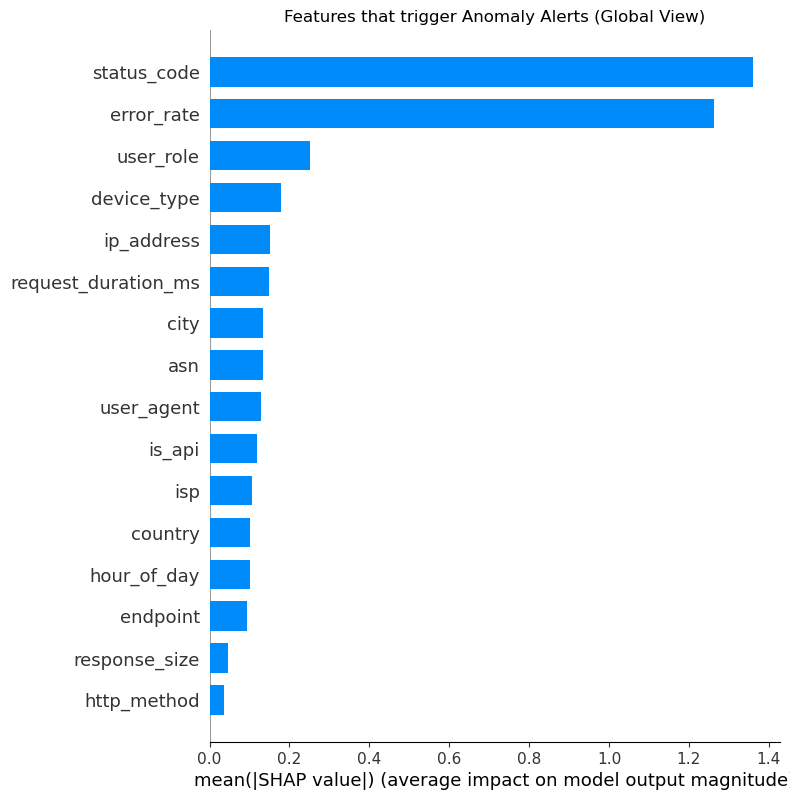


--- LOCAL EXPLANATION (Waterfall Plot for the #1 worst anomaly) ---


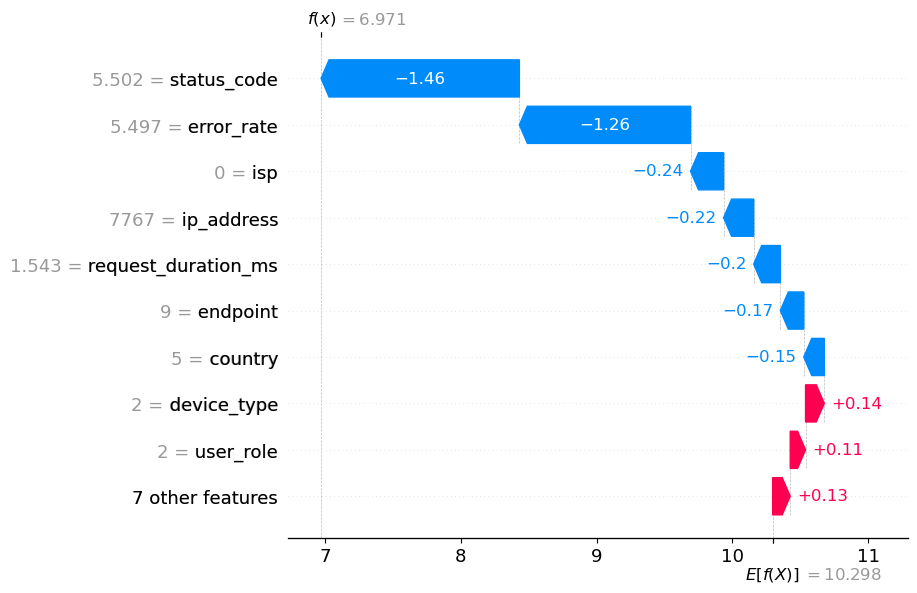

In [140]:
import shap
import matplotlib.pyplot as plt



# 1. Initialize Javascript for interactive charts (Required for Jupyter Notebooks)
shap.initjs()

# 2. Create the SHAP Explainer
# We feed your trained Isolation Forest into the SHAP TreeExplainer
print("Initializing SHAP Explainer... (This is opening the black box)")
explainer = shap.TreeExplainer(iso_forest)

# 3. Filter the Data
# Explaining all 100,000 rows takes too long and isn't useful. 
# We only care about explaining the "Attacks" (the anomalies our AI found in Step 4).
# We use the index of the anomalies from the original dataframe to get the scaled data.
anomaly_indices = df[df['is_anomaly'] == -1].index
anomalies_scaled = df_processed.loc[anomaly_indices]

# Calculate SHAP values for these specific anomalies
print("Calculating SHAP values for the anomalies...")
shap_values = explainer.shap_values(anomalies_scaled)

# 4. Global Explanation: The Summary Bar Chart
# This answers: "Across ALL anomalies, what are the most suspicious features?"
print("\n--- GLOBAL EXPLANATION (Summary Plot) ---")
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, anomalies_scaled, plot_type="bar", show=False)
plt.title("Features that trigger Anomaly Alerts (Global View)")
plt.show()

# 5. Local Explanation: The Waterfall Chart for a Single Attack
# This answers: "Why was THIS SPECIFIC log flagged as a threat?"
print("\n--- LOCAL EXPLANATION (Waterfall Plot for the #1 worst anomaly) ---")
# We take the first anomaly in our list
single_anomaly_index = 0  

# For Isolation Forest, SHAP sometimes outputs an array of arrays depending on the version.
# We handle the format to ensure the waterfall plot works perfectly.
if isinstance(shap_values, list):
    shap_vals_single = shap_values[0][single_anomaly_index]
else:
    shap_vals_single = shap_values[single_anomaly_index]

# Create an Explanation object for the single row
explanation = shap.Explanation(values=shap_vals_single, 
                               base_values=explainer.expected_value[0] if isinstance(explainer.expected_value, list) else explainer.expected_value, 
                               data=anomalies_scaled.iloc[single_anomaly_index], 
                               feature_names=df_processed.columns)

# Draw the waterfall plot
shap.plots.waterfall(explanation)

In [142]:
import numpy as np

# ================================
# STEP 5b: XAI THREAT ANALYSIS REPORT
# ================================


# -------------------------------
# 1. DATA EXTRACTION
# -------------------------------
actual_df_index = anomaly_indices[single_anomaly_index]
original_anomaly = df.loc[actual_df_index]
scaled_row = df_processed.loc[actual_df_index]

if isinstance(shap_values, list):
    row_shap = shap_values[0][single_anomaly_index]
else:
    row_shap = shap_values[single_anomaly_index]

# -------------------------------
# 2. FEATURE IMPACT ANALYSIS
# -------------------------------
top_feature_indices = np.argsort(np.abs(row_shap))[::-1][:2]

trigger_1_name = df_processed.columns[top_feature_indices[0]]
trigger_2_name = df_processed.columns[top_feature_indices[1]]

trigger_1_value = original_anomaly.get(trigger_1_name, scaled_row[trigger_1_name])
trigger_2_value = original_anomaly.get(trigger_2_name, scaled_row[trigger_2_name])

# -------------------------------
# 3. THREAT INTELLIGENCE MAPPING
# -------------------------------
threat_intel_db = {
    'status_code': "Abnormal HTTP status behavior may indicate probing, exploitation attempts, or misconfigured attack traffic.",
    'error_rate': "Elevated error rates are consistent with brute-force activity or automated scanning tools.",
    'response_size': "Significant deviation in response size may indicate data exfiltration or payload manipulation.",
    'request_duration_ms': "Unusual latency patterns may indicate denial-of-service behavior or injection-heavy requests.",
    'hour_of_day': "Off-hours activity may indicate automated or geographically distributed attacker infrastructure.",
    'device_type': "Non-standard or scripted clients may indicate automated attack tooling or spoofed user agents.",
    'user_role': "Privilege boundary violations may indicate escalation attempts.",
    'country': "Unexpected geolocation patterns may indicate proxy use, VPN tunneling, or botnet activity.",
    'endpoint': "Targeting of sensitive endpoints suggests reconnaissance or exploitation attempts.",
    'http_method': "Unexpected HTTP verbs may indicate unauthorized operations or API abuse.",
    'ip_address': "Behavioral deviation from baseline strongly suggests malicious or anomalous source activity."
}

explanation_1 = threat_intel_db.get(trigger_1_name, "Anomalous deviation detected in feature behavior.")
explanation_2 = threat_intel_db.get(trigger_2_name, "Anomalous deviation detected in feature behavior.")

# ================================
# 4. REPORT OUTPUT
# ================================

print("\n" + "=" * 90)
print("                SECURITY INCIDENT ANALYSIS REPORT")
print("=" * 90)

print(f"\nIncident ID        : {single_anomaly_index}")
print(f"Data Index         : {actual_df_index + 1}")
print(f"Source IP          : {original_anomaly['ip_address']}")
print(f"Timestamp          : {original_anomaly['timestamp']}")

print("\n" + "-" * 90)
print("PRIMARY RISK DRIVERS (SHAP EXPLANATION)")
print("-" * 90)

print(f"\n[1] Feature        : {trigger_1_name}")
print(f"    Observed Value : {trigger_1_value}")
print(f"    Interpretation : {explanation_1}")

print(f"\n[2] Feature        : {trigger_2_name}")
print(f"    Observed Value : {trigger_2_value}")
print(f"    Interpretation : {explanation_2}")

print("\n" + "-" * 90)
print("TRAFFIC CONTEXT")
print("-" * 90)

print(f"HTTP Method        : {original_anomaly['http_method']}")
print(f"Endpoint           : {original_anomaly['endpoint']}")
print(f"Status Code        : {original_anomaly['status_code']}")
print(f"Device Type        : {original_anomaly['device_type']}")
print(f"User Role          : {original_anomaly['user_role']}")
print(f"Country            : {original_anomaly['country']}")
print(f"Response Size      : {original_anomaly['response_size']} bytes")
print(f"Request Duration   : {original_anomaly['request_duration_ms']} ms")

print("\n" + "=" * 90)
print("CLASSIFICATION: POTENTIAL SECURITY THREAT")
print("=" * 90 + "\n")


                SECURITY INCIDENT ANALYSIS REPORT

Incident ID        : 0
Data Index         : 176
Source IP          : 119.248.1.148
Timestamp          : 2025-03-23T12:33:05.930079

------------------------------------------------------------------------------------------
PRIMARY RISK DRIVERS (SHAP EXPLANATION)
------------------------------------------------------------------------------------------

[1] Feature        : status_code
    Observed Value : 404
    Interpretation : Abnormal HTTP status behavior may indicate probing, exploitation attempts, or misconfigured attack traffic.

[2] Feature        : error_rate
    Observed Value : 1
    Interpretation : Elevated error rates are consistent with brute-force activity or automated scanning tools.

------------------------------------------------------------------------------------------
TRAFFIC CONTEXT
------------------------------------------------------------------------------------------
HTTP Method        : GET
Endpoint      

In [124]:
# --- Quick Diagnostic: Find Unique Risk Categories ---
import numpy as np

unique_drivers = {}

print("Scanning your 1,000 anomalies for diverse risk drivers...\n")

# Loop through all 1,000 anomalies to see what their #1 trigger is
for tracker_id in range(len(anomaly_indices)):
    # Grab the SHAP values for this specific tracking ID
    if isinstance(shap_values, list):
        row_shap = shap_values[0][tracker_id]
    else:
        row_shap = shap_values[tracker_id]
        
    # Find the absolute top feature index for this row
    top_feature_idx = np.argsort(np.abs(row_shap))[::-1][0]
    primary_driver = df_processed.columns[top_feature_idx]
    
    # If we haven't seen this feature act as a primary driver yet, save it!
    if primary_driver not in unique_drivers:
        unique_drivers[primary_driver] = tracker_id

# Print the results perfectly for you to copy/paste
print("🎯 FOUND THEM! Use these index numbers to see completely different outputs:")
print("-" * 75)
for driver, tracker_id in unique_drivers.items():
    print(f"👉 To test an anomaly caused by {driver.upper():<20} -> set single_anomaly_index = {tracker_id}")
print("-" * 75)

Scanning your 1,000 anomalies for diverse risk drivers...

🎯 FOUND THEM! Use these index numbers to see completely different outputs:
---------------------------------------------------------------------------
👉 To test an anomaly caused by STATUS_CODE          -> set single_anomaly_index = 0
👉 To test an anomaly caused by ERROR_RATE           -> set single_anomaly_index = 4
👉 To test an anomaly caused by USER_ROLE            -> set single_anomaly_index = 76
---------------------------------------------------------------------------


In [125]:
# Cell 6: Presentation / Dashboard

In [143]:
# PATH
# streamlit run app.py

In [144]:
import os
os.getcwd()

'C:\\Users\\STAR\\Threats prediction with XAI'